In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

# Metallicity dependance equations in Weinberg et al. 2019 (Chemical Cartography)

I will note this paper as W2019 

In [2]:
def get_y_x(y_ref, Z_x_solar, Z_ref_solar, alpha_cc, Z_ref_normalized):
    """
    Eq. 17 in W2019
    Parameters
    ----------
    y_ref : float
        Ref element yield. 
    Z_x_solar : float
        Element X abundance in the Sun
    Z_ref_solar : float
        Ref element abundance in the Sun
    alpha_cc : float
        Slope alpha
    Z_ref_normalized : ndarray
        [REF/H] for the population

    Returns
    -------
    y_X : ndarray
        yield for elemnt X dependent on ref metallicity
    """
    y_x = y_ref * (Z_x_solar/Z_ref_solar) * 10**(alpha_cc * Z_ref_normalized)
    return y_x



SolarO = 0.0056		# solar oxygen abundance by mass
SolarFe = 0.0012		# solar iron abundance by mass

def ratio_to_sun(star, sun):
    return np.log10(star/sun + 1e-10)

In [3]:
def get_abundance_by_mass(table_value):
    abundance = 10**(table_value - 12)
    return abundance
val = 5.52 #Mn
Mn_mass = 54.938
SolarMn = get_abundance_by_mass(val) * Mn_mass

In [4]:
t_array = np.linspace(0,14,int(1e4))
model = evo.Galaxy(t_array)
m_g_array_const = np.ones(len(t_array))
Z_oxygen_const = model.compute_z_O(m_g_array_const)
Z_Iron_const = model.compute_z_Fe(m_g_array_const)

Fe_H = ratio_to_sun(Z_Iron_const, SolarFe)
O_H = ratio_to_sun(Z_oxygen_const, SolarO)

m_g_array_const = np.ones(len(t_array))
Z_oxygen_const = model.compute_z_O(m_g_array_const)
Z_Iron_const = model.compute_z_Fe(m_g_array_const)
eq_Iron_const = model.analytic_eq_Fe("constant")

Fe_H = ratio_to_sun(Z_Iron_const, SolarFe)
O_H = ratio_to_sun(Z_oxygen_const, SolarO)

In [5]:
#Assume ref element is O
#Let's look at Iron first

alpha_cc_test = 0.0
y_depend = get_y_x(y_ref=model.m_o_cc_arr[0], Z_x_solar=SolarFe, Z_ref_solar=SolarO, alpha_cc=alpha_cc_test, Z_ref_normalized=O_H)

I have "a" yield equation, now it's time to do the Mdotstar integration numerically, and chug in the yield in that, and see how it looks like.

In [38]:
def R_t(t, t_D=0.15, R_0=(1.47*10**-3), tau_Ia=1.5):
    DTD_function = R_0 * np.exp(-(t - t_D)/tau_Ia)
    DTD_function[np.where(t < t_D)] = 0
    return DTD_function

In [ ]:
dt = t_array[1] - t_array[0]
r_DTD = R_t(t_array)
m_Fe_Ia = np.zeros(len(t_array))
K_Fe_Ia = 0.77 * np.ones(len(m_Fe_Ia))

for i in range(1,len(t_array)):
    m_Fe_Ia[i] = m_Fe_Ia[i-1] + K_Fe_Ia[i-1] * r_DTD[i-1] * dt

In [40]:
integral = np.trapezoid(r_DTD * K_Fe_Ia, t_array)
integral

np.float64(0.001697101125971701)

In [44]:
m_Fe_Ia

array([0.       , 0.       , 0.       , ..., 0.0016971, 0.0016971,
       0.0016971], shape=(10000,))

In [47]:
model2 = evo.Galaxy(t_array=t_array, m_Fe_Ia=m_Fe_Ia[-1])
Z_Iron_metal_dep = model2.compute_z_Fe(m_g_array_const)
eq_metal_dep = model2.analytic_eq_Fe(SFR_function="constant")

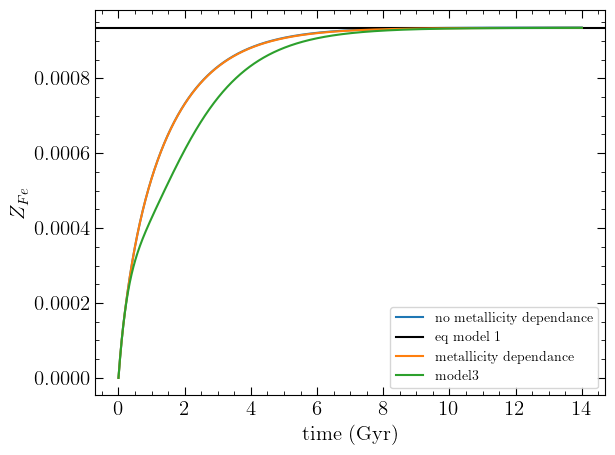

In [ ]:
#plt.plot(t_array, m_Fe_Ia)
plt.plot(t_array, Z_Iron_const, label = 'no metallicity dependance')
plt.axhline(eq_Iron_const, color = 'black', label = 'eq model 1')
plt.plot(t_array, Z_Iron_metal_dep, label = 'metallicity dependance')

plt.legend()
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.tight_layout()

In [13]:
m1 = np.exp(0.1) * 0.77 * 2.2 * 1.5 * 10**-3 
m2 = 0.77 * 2.2 * 1.5 * 10**-3 
print(m1)
print(m2)

0.0028082393028302215
0.0025410000000000003


In [14]:
2.2 * 10**-3 * 0.77

0.0016940000000000002

In [15]:
np.exp(-(15 - 0.15)/0.15)

np.float64(1.0112214926104486e-43)

In [16]:
2.2/1.5

1.4666666666666668